In [ ]:
from git import Repo
import os
import ast
import re
import numpy as np
import logging
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path

## Part 1 - Code coverage

In [18]:
def list_folders(directory):
    return [
        folder.name
        for folder in Path(directory).iterdir()
        if folder.is_dir()
    ]

In [ ]:
list_coverage = list_folders("./coverageHistory")

In [ ]:
coverage_history_files = {}
coverage_history_functions = {}
coverage_history_classes = {}

for folder in list_coverage:
    base_dir = f"./coverageHistory/{folder}/"
    files_coverage_html = base_dir + "index.html"
    functions_coverage_html = base_dir + "function_index.html"
    classes_coverage_html = base_dir + "class_index.html"

    files_coverage = pd.read_html(files_coverage_html)
    functions_coverage = pd.read_html(functions_coverage_html)
    classes_coverage = pd.read_html(classes_coverage_html)

    files_coverage_df = files_coverage[0]
    functions_coverage_df = functions_coverage[0]
    classes_coverage_df = classes_coverage[0]

    # Get the last column of each DataFrame
    total_cov_files = files_coverage_df.iloc[:, -1]
    total_cov_functions = functions_coverage_df.iloc[:, -1]
    total_cov_classes = classes_coverage_df.iloc[:, -1]

    # Count rows where the value is 100%
    cov_files_100 = (total_cov_files == "100%").sum()
    cov_functions_100 = (total_cov_functions == "100%").sum()
    cov_classes_100 = (total_cov_classes == "100%").sum()

    # Count rows where the value is between 90% and 100%
    cov_files_90_99 = ((total_cov_files >= "90%") & (total_cov_files < "100%")).sum()
    cov_functions_90_99 = ((total_cov_functions >= "90%") & (total_cov_functions < "100%")).sum()
    cov_classes_90_99 = ((total_cov_classes >= "90%") & (total_cov_classes < "100%")).sum()

    # Count rows where the value is less than 90%
    cov_files_89 =(total_cov_files < "90%").sum()
    cov_functions_89 =(total_cov_functions < "90%").sum()
    cov_classes_89 =(total_cov_classes < "90%").sum()

    # Number of rows
    nb_files = len(files_coverage_df)
    nb_functions = len(functions_coverage_df)
    nb_classes = len(classes_coverage_df)

    # Divide count of 100% by number of rows
    ratio_files_100 = cov_files_100 / nb_files
    ratio_functions_100 = cov_functions_100 / nb_functions
    ratio_classes_100 = cov_classes_100 / nb_classes

    # Divide count of 90-99% by number of rows
    ratio_files_90_99 = cov_files_90_99 / nb_files
    ratio_functions_90_99 = cov_functions_90_99 / nb_functions
    ratio_classes_90_99 = cov_classes_90_99 / nb_classes

    # Divide count of less than 90% by number of rows
    ratio_files_89 = cov_files_89 / nb_files
    ratio_functions_89 = cov_functions_89 / nb_functions
    ratio_classes_89 = cov_classes_89 / nb_classes

    dict_files = {}
    dict_files["ratio_files_100"] = [ratio_files_100]
    dict_files["ratio_files_90_99"] = [ratio_files_90_99]
    dict_files["ratio_files_89"] = [ratio_files_89]
    dict_functions = {}
    dict_functions["ratio_functions_100"] = [ratio_functions_100]
    dict_functions["ratio_functions_90_99"] = [ratio_functions_90_99]
    dict_functions["ratio_functions_89"] = [ratio_functions_89]
    dict_classes = {}
    dict_classes["ratio_classes_100"] = [ratio_classes_100]
    dict_classes["ratio_classes_90_99"] = [ratio_classes_90_99]
    dict_classes["ratio_classes_89"] = [ratio_classes_89]

    coverage_history_files[folder] = dict_files
    coverage_history_functions[folder] = dict_functions
    coverage_history_classes[folder] = dict_classes

In [30]:
coverage_history_files

{'htmlcov03-02': {'ratio_files_100': [np.float64(0.36363636363636365)],
  'ratio_files_90_99': [np.float64(0.0)],
  'ratio_files_89': [np.float64(0.6136363636363636)]},
 'htmlcov03-09': {'ratio_files_100': [np.float64(0.36363636363636365)],
  'ratio_files_90_99': [np.float64(0.0)],
  'ratio_files_89': [np.float64(0.6136363636363636)]},
 'htmlcov03-16': {'ratio_files_100': [np.float64(0.3409090909090909)],
  'ratio_files_90_99': [np.float64(0.0)],
  'ratio_files_89': [np.float64(0.5909090909090909)]},
 'htmlcov03-23': {'ratio_files_100': [np.float64(0.3409090909090909)],
  'ratio_files_90_99': [np.float64(0.0)],
  'ratio_files_89': [np.float64(0.5909090909090909)]},
 'htmlcov03-30': {'ratio_files_100': [np.float64(0.3409090909090909)],
  'ratio_files_90_99': [np.float64(0.0)],
  'ratio_files_89': [np.float64(0.5909090909090909)]},
 'htmlcov04-06': {'ratio_files_100': [np.float64(0.3409090909090909)],
  'ratio_files_90_99': [np.float64(0.0)],
  'ratio_files_89': [np.float64(0.59090909090

In [31]:
# we save the coverage history in three separate CSV files
with open('./coverage_history_files.csv', 'w', newline='') as csvfile:
    fieldnames = ['file', 'ratio_files_100', 'ratio_files_90_99', 'ratio_files_89']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    writer.writeheader()
    for file, ratios in coverage_history_files.items():
        row = {'file': file}
        row.update(ratios)
        writer.writerow(row)

with open('./coverage_history_functions.csv', 'w', newline='') as csvfile:
    fieldnames = ['file', 'ratio_functions_100', 'ratio_functions_90_99', 'ratio_functions_89']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    writer.writeheader()
    for file, ratios in coverage_history_functions.items():
        row = {'file': file}
        row.update(ratios)
        writer.writerow(row)

with open('./coverage_history_classes.csv', 'w', newline='') as csvfile:
    fieldnames = ['file', 'ratio_classes_100', 'ratio_classes_90_99', 'ratio_classes_89']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    writer.writeheader()
    for file, ratios in coverage_history_classes.items():
        row = {'file': file}
        row.update(ratios)
        writer.writerow(row)

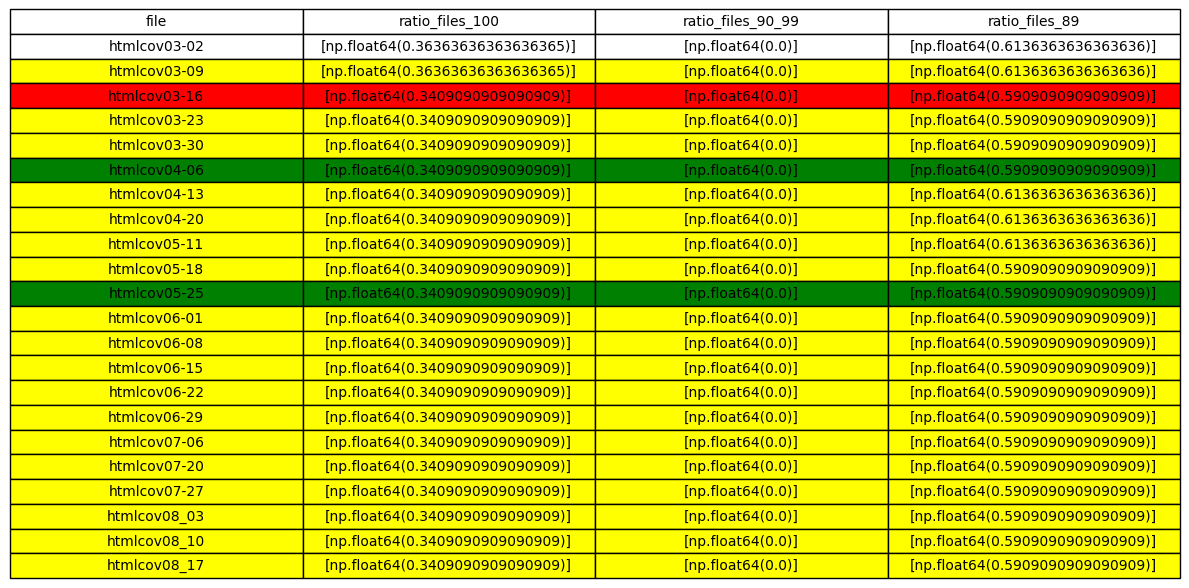

In [38]:
# Read the coverage history
df = pd.read_csv('./coverage_history_files.csv')

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Color rows according to the first column
for i in range(len(df)):

    # Skip comparison for first data row
    if i == 0:
        color = "white"
    else:
        current = df.iloc[i, 1] # read the value of the 100% ratio for comparison
        previous = df.iloc[i - 1, 1]

        #-----added to see more changes-----
        if i == 5 or i == 10:
            previous = str(0)
        #-----------------------------------

        if current < previous: # if it is lower, we indicate it in red
            color = "red"
        elif current > previous: # if it is higher, we indicate it in green
            color = "green"
        else:
            color = "yellow" # else, we indicate it in yellow

    table_row = i + 1

    # Apply color to every cell in the row
    for col in range(len(df.columns)):
        table[(table_row, col)].set_facecolor(color)

plt.tight_layout()
plt.show()

## Part 2 - Readability score

In [2]:
def get_git_branches(repo_url):
    api_url = f"{repo_url.rstrip('/')}/info/refs?service=git-upload-pack"
    response = requests.get(api_url, stream=True)
    print(api_url)
    print(response)

    branches = []
    for line in response.iter_lines(decode_unicode=True):
        if line.startswith("refs/heads/"):
            branch_name = line.split("refs/heads/")[-1]
            branches.append(branch_name)
    
    return branches

In [3]:
def extract_identifiers_python(code):
    """Extract function, variable, and class names using AST."""
    try:
        tree = ast.parse(code)
    except SyntaxError as e:
        logger.error('Syntax error in Python code: %s', e)
        return set()

    identifiers = set()

    for node in ast.walk(tree):
        if isinstance(node, ast.FunctionDef):
            identifiers.add(node.name)
            identifiers.update(arg.arg for arg in node.args.args)
        elif isinstance(node, ast.ClassDef):
            identifiers.add(node.name)
        elif isinstance(node, ast.Name):
            identifiers.add(node.id)
    return identifiers

def extract_identifiers_java(code: str):
    identifiers = set()
    # Remove comments and strings to avoid noise
    code = re.sub(r'//.*|/\*[\s\S]*?\*/|".*?"', '', code)

    # Classes and interfaces
    identifiers.update(re.findall(r'\b(class|interface)\s+([A-Z][A-Za-z0-9_]*)', code))
    identifiers = {name for _, name in identifiers}

    # Methods
    identifiers.update(re.findall(r'\b([a-zA-Z_][a-zA-Z0-9_]*)\s*\([^)]*\)\s*\{', code))

    # Variables
    identifiers.update(re.findall(r'\b(?:int|float|double|String|boolean|char|long|var)\s+([a-zA-Z_][a-zA-Z0-9_]*)', code))
    return identifiers

def extract_identifiers_c(code: str):
    identifiers = set()
    # Remove comments and strings
    code = re.sub(r'//.*|/\*[\s\S]*?\*/|".*?"', '', code)

    # Functions
    identifiers.update(re.findall(r'\b([a-zA-Z_][a-zA-Z0-9_]*)\s*\([^)]*\)\s*\{', code))

    # Variables (simple types)
    identifiers.update(re.findall(r'\b(?:int|float|double|char|long|short|void|bool)\s+([a-zA-Z_][a-zA-Z0-9_]*)', code))
    return identifiers

In [ ]:
clone_dir_path = "/Users/lamartp/Documents"
clone_dir_path = clone_dir_path+"/black"

In [6]:
repo = Repo(clone_dir_path)

In [7]:
#create a list of all files in the repository
file_paths = []
for root, dirs, files in os.walk(repo.working_tree_dir):
    for file in files:
        if file.endswith('.c') or file.endswith('.java') or file.endswith('.py'):
            file_paths.append(os.path.relpath(os.path.join(root, file), repo.working_tree_dir))
            #print(os.path.relpath(os.path.join(root, file), repo.working_tree_dir))

In [8]:
generic_names = {"data", "temp", "value", "var", "info", "item", "obj", "thing", "res", "result", "flag", "list"}

In [9]:
logging.basicConfig(filename='./Readability.log', 
                    filemode='w',
                    format='%(asctime)s;%(name)s;%(levelname)s;%(message)s',
                    level=logging.DEBUG)

logger = logging.getLogger('Identifier_Readability')

In [ ]:
file_scores = {}

for file in file_paths:
    logger.info('Logging for file: %s', file)

    file_to_read = os.path.join(clone_dir_path, file)
    with open(file_to_read, 'r') as code:
        content = code.read()

    # Extract identifiers based on file type
    if file.endswith('.py'):
        identifier_list = extract_identifiers_python(content)
    elif file.endswith('.java'):
        identifier_list = extract_identifiers_java(content)
    elif file.endswith('.c'):
        identifier_list = extract_identifiers_c(content)

    if len(identifier_list) == 0:
        logger.warning('error: no identifier found')
    else:
        logger.info('Identifier count: %d', len(identifier_list))

    # Initialize variables
    snake = camel = other = 0
    mixed_conventions = False
    total_word_count = 0
    generic_count = 0

    for identifier in identifier_list:
        generic_count_identifier = 0 #used only for information quality check
        
        # Split identifier into words
        words = re.sub(r'([a-z])([A-Z])', r'\1_\2', identifier)
        words = re.findall(r"[a-zA-Z]+", words.lower())

        total_word_count += len(words)

        # Determine naming convention
        if len(words)>=2:
            if "_" in identifier:
                snake += 1
            elif re.search(r"[a-z][A-Z]", identifier):
                camel += 1
            else:
                other += 1

        # Count the number of variables using generic names
        if any(word in generic_names for word in words):
            generic_count += 1
            generic_count_identifier += 1
        
    # If there is multiple conventions, set mixed_conventions to True
    if sum([snake>0, camel>0, other>0])>=2:
        mixed_conventions = True

    # We save the convention(s) used
    convention = []
    if snake>0:
        convention.append("snake_case")
    if camel>0:
        convention.append("camelCase")
    if other>0:
        convention.append("other")

    # Calculate the proportion of generic names to total names
    if len(identifier_list)>0: 
        generic_penalty = generic_count / len(identifier_list)
    else:
        generic_penalty = 0

    # Calculate a penalty for the identifier names length
    # If the average length is not between 8 and 12 characters, we apply a penalty based on how far it is from this range
    if len(identifier_list)>0: 
        avg_length = sum(len(identifier) for identifier in identifier_list) / len(identifier_list)
    else:
        avg_length = 0
    
    if 8 <= avg_length <= 12:
        length_penalty = 0
    elif avg_length < 0:
        length_penalty = 0
    else:
        length_penalty = min(abs(8 - avg_length), abs(avg_length - 12))/3

    # Calculate a penalty for the average number of words in the identifier names
    # If the average number of words is more than 2, we apply a penalty based on how far it is from this value
    if len(identifier_list)>0: 
        avg_word_count = total_word_count / len(identifier_list)
    else: 
        avg_word_count = 0

    if 0 < avg_word_count <= 2:
        word_count_penalty = 0
    elif avg_word_count < 0:
        word_count_penalty = 0
    else:
        word_count_penalty = avg_word_count - 2

    # Combine all penalties into a final score. Weights can be adjusted as needed.
    penalty_score = (0.25 * mixed_conventions + 0.25 * generic_penalty + 0.25 * length_penalty + 0.25 * word_count_penalty)

    dict = {}
    dict["penalty score"] = penalty_score
    dict["mixed convention"] = mixed_conventions
    dict["generic penalty"] = generic_penalty
    dict["length penalty"] = length_penalty
    dict["word count penalty"] = word_count_penalty
    dict["convention"] = convention
    file_scores[file] = dict


action\main.py
docs\conf.py
profiling\dict_big.py
profiling\dict_huge.py
profiling\list_big.py
profiling\list_huge.py
profiling\mix_big.py
profiling\mix_huge.py
profiling\mix_small.py
scripts\check_pre_commit_rev_in_example.py
scripts\check_version_in_basics_example.py
scripts\diff_shades_gha_helper.py
scripts\fuzz.py
scripts\generate_schema.py
scripts\make_width_table.py
scripts\migrate-black.py
scripts\release.py
scripts\release_tests.py
scripts\__init__.py
src\_black_version.py
src\black\brackets.py
src\black\cache.py
src\black\comments.py
src\black\concurrency.py
src\black\const.py
src\black\debug.py
src\black\files.py
src\black\handle_ipynb_magics.py
src\black\linegen.py
src\black\lines.py
src\black\mode.py
src\black\nodes.py
src\black\numerics.py
src\black\output.py
src\black\parsing.py
src\black\ranges.py
src\black\report.py
src\black\rusty.py
src\black\schema.py
src\black\strings.py
src\black\trans.py
src\black\_width_table.py
src\black\__init__.py
src\black\__main__.py
src\bla

<unknown>:163: SyntaxWarning: invalid escape sequence '\ '
<unknown>:169: SyntaxWarning: invalid escape sequence '\ '
<unknown>:174: SyntaxWarning: invalid escape sequence '\ '
<unknown>:179: SyntaxWarning: invalid escape sequence '\ '
<unknown>:226: SyntaxWarning: invalid escape sequence '\ '
<unknown>:391: SyntaxWarning: invalid escape sequence '\ '
<unknown>:397: SyntaxWarning: invalid escape sequence '\ '
<unknown>:402: SyntaxWarning: invalid escape sequence '\ '
<unknown>:408: SyntaxWarning: invalid escape sequence '\ '
<unknown>:455: SyntaxWarning: invalid escape sequence '\ '
<unknown>:108: SyntaxWarning: invalid escape sequence '\ '
<unknown>:114: SyntaxWarning: invalid escape sequence '\ '
<unknown>:119: SyntaxWarning: invalid escape sequence '\ '
<unknown>:234: SyntaxWarning: invalid escape sequence '\ '
<unknown>:240: SyntaxWarning: invalid escape sequence '\ '
<unknown>:245: SyntaxWarning: invalid escape sequence '\ '


tests\data\cases\docstring2.py
tests\data\cases\docstring_newline.py
tests\data\cases\docstring_no_extra_empty_line_before_eof.py
tests\data\cases\docstring_no_string_normalization.py
tests\data\cases\dummy_implementations.py
tests\data\cases\empty_lines.py
tests\data\cases\expression.py
tests\data\cases\fmtonoff.py
tests\data\cases\fmtonoff2.py
tests\data\cases\fmtonoff3.py
tests\data\cases\fmtonoff4.py
tests\data\cases\fmtonoff5.py
tests\data\cases\fmtonoff6.py
tests\data\cases\fmtpass_imports.py
tests\data\cases\fmtskip.py
tests\data\cases\fmtskip10.py
tests\data\cases\fmtskip11.py
tests\data\cases\fmtskip12.py
tests\data\cases\fmtskip13.py
tests\data\cases\fmtskip2.py
tests\data\cases\fmtskip3.py
tests\data\cases\fmtskip4.py
tests\data\cases\fmtskip5.py
tests\data\cases\fmtskip6.py
tests\data\cases\fmtskip7.py
tests\data\cases\fmtskip8.py
tests\data\cases\fmtskip9.py
tests\data\cases\fmtskip_multiple_in_clause.py
tests\data\cases\fmtskip_multiple_strings.py
tests\data\cases\format_

<unknown>:134: SyntaxWarning: invalid escape sequence '\{'
<unknown>:135: SyntaxWarning: invalid escape sequence '\{'
<unknown>:135: SyntaxWarning: invalid escape sequence '\}'
<unknown>:136: SyntaxWarning: invalid escape sequence '\{'
<unknown>:273: SyntaxWarning: invalid escape sequence '\{'
<unknown>:274: SyntaxWarning: invalid escape sequence '\{'
<unknown>:274: SyntaxWarning: invalid escape sequence '\}'
<unknown>:275: SyntaxWarning: invalid escape sequence '\{'


tests\data\cases\prefer_rhs_split.py
tests\data\cases\prefer_rhs_split_reformatted.py
tests\data\cases\preview_cantfit_string.py
tests\data\cases\preview_comments7.py
tests\data\cases\preview_fstring.py
tests\data\cases\preview_hug_parens_with_braces_and_square_brackets.py
tests\data\cases\preview_hug_parens_with_braces_and_square_brackets_no_ll1.py
tests\data\cases\preview_long_dict_values.py
tests\data\cases\preview_long_strings.py
tests\data\cases\preview_long_strings__east_asian_width.py
tests\data\cases\preview_long_strings__edge_case.py
tests\data\cases\preview_long_strings__regression.py
tests\data\cases\preview_remove_multiline_lone_list_item_parens.py
tests\data\cases\preview_return_annotation_brackets_string.py
tests\data\cases\preview_simplify_power_operator_hugging.py
tests\data\cases\preview_simplify_power_operator_hugging_long.py
tests\data\cases\preview_wrap_comprehension_in.py
tests\data\cases\py310_pep572.py
tests\data\cases\python37.py
tests\data\cases\python38.py
tes

In [ ]:
snake_count = 0
camel_count = 0
other_count = 0
mixed_count = 0

sum_generic_penalty = 0
sum_length_penalty = 0
sum_word_count_penalty = 0
sum_penalty_score = 0

for file, scores in file_scores.items():
    if "snake_case" in scores["convention"]:
        snake_count += 1
    if "camelCase" in scores["convention"]:
        camel_count += 1
    if "other" in scores["convention"]:
        other_count += 1
    if scores["mixed convention"]:
        mixed_count += 1

    sum_generic_penalty += scores["generic penalty"]
    sum_length_penalty += scores["length penalty"]
    sum_word_count_penalty += scores["word count penalty"]
    sum_penalty_score += scores["penalty score"]

if len(file_scores) != 0:    
    global_generic_penalty = sum_generic_penalty / len(file_scores)
    global_length_penalty = sum_length_penalty / len(file_scores)
    global_word_count_penalty = sum_word_count_penalty / len(file_scores)
    global_penalty_score = sum_penalty_score / len(file_scores)

with open('./Readability_Scores.csv', 'w', newline='') as csvfile:
    fieldnames = ['file', 'penalty score', 'mixed convention', 'generic penalty', 'length penalty', 'word count penalty', 'convention']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    writer.writeheader()
    for file, scores in file_scores.items():
        row = {'file': file}
        row.update(scores)
        writer.writerow(row)

print(snake_count, camel_count, other_count, mixed_count)


176 98 3 85


In [12]:
if global_generic_penalty>2 or global_generic_penalty<0:
    color_generic = "red"
else:
    color_generic = "green"

if global_length_penalty>2 or global_length_penalty<0:
    color_length = "red"
else:
    color_length = "green"

if global_word_count_penalty>2 or global_word_count_penalty<0:
    color_word_count = "red"
else:
    color_word_count = "green"

if mixed_count>0 or sum([snake_count>0, camel_count>0, other_count>0])>2:
    color_convention = "red"
else:
    color_convention = "green"

In [ ]:
columns = ("Readability Score", "Value")
rows = ["Generic Word Penalty", "Word Length Penalty", "Word Count Penalty", "Mixed Convention Penalty"]
cell_text = [[f"Generic Word Penalty: {global_generic_penalty}"], 
             [f"Word Length Penalty: {global_length_penalty}"], 
             [f"Word Count Penalty: {global_word_count_penalty}"], 
             [f"Mixed Convention Penalty: {mixed_count + sum([snake_count>0, camel_count>0, other_count>0])>2}"]]
colors = [[color_generic], 
          [color_length], 
          [color_word_count],
          [color_convention]]


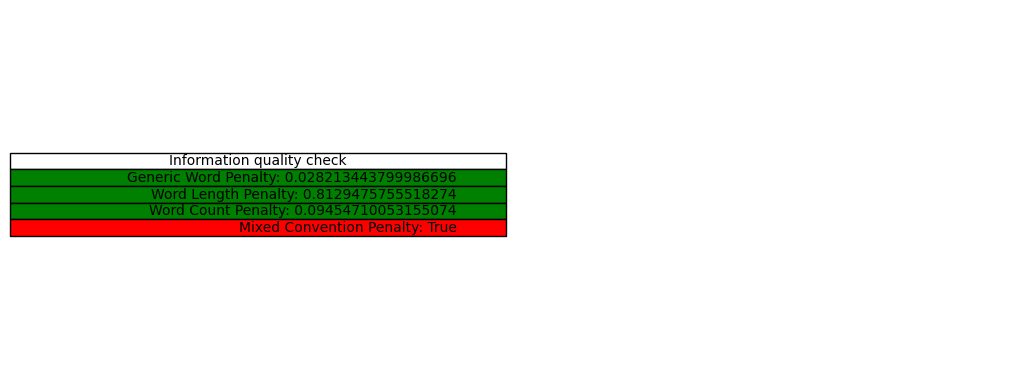

In [14]:
fig, ax = plt.subplots()
ax.axis("tight")
ax.axis("off")
the_table = ax.table(cellText=cell_text,
                     cellColours=colors,
                     colLabels=columns,
                     loc="left")

plt.show()

In [15]:
logger.info('Configuration ended')
logging.shutdown()

In [16]:
fieldnames = ['penalty score', 'mixed convention', 'generic penalty', 'length penalty', 'word count penalty', 'convention']
convention_count = [snake_count, camel_count, other_count]

with open('./Global_Readability_Scores.csv', 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    row = {'penalty score': global_penalty_score,
           'mixed convention': mixed_count,
           'generic penalty': global_generic_penalty,
           'length penalty': global_length_penalty,
           'word count penalty': global_word_count_penalty,
           'convention': convention_count}
    writer.writerow(row)